# Buổi 4: Tìm kiếm trong không gian trạng thái

## Bài tập 2:
Bài toán **Mê cung**: Tìm đường đi để con kiến có thể đi tới ô A trong mê cung cho bên dưới: <br>
<br>
![image](mecung.png)

## Bài làm


**maze.inp**
```
(Dựa theo dòng cột base 1)
6           # m = 6
6           # n = 6
1 2 1 3     # tường giữa ô [1,2] và [1,3]
2 2 2 3
3 5 4 5
3 6 4 6
5 2 5 3
6 2 6 3
```

### Đọc dữ liệu

In [31]:
from ex2_maze import readfile
wall_list, maze = readfile()

Ma trận : 
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
Danh sách vị trí các tường
[((np.int64(1), np.int64(2)),(np.int64(1), np.int64(3))), ((np.int64(2), np.int64(2)),(np.int64(2), np.int64(3))), ((np.int64(3), np.int64(5)),(np.int64(4), np.int64(5))), ((np.int64(3), np.int64(6)),(np.int64(4), np.int64(6))), ((np.int64(5), np.int64(2)),(np.int64(5), np.int64(3))), ((np.int64(6), np.int64(2)),(np.int64(6), np.int64(3)))]


### Tìm đường đi từ ô (1,1) đến ô (6,6) của mê cung bằng BFS

In [32]:
import pprint
from ex2_maze import find_path_BFS

#..
parent = find_path_BFS(maze, wall_list, 1, 1, 6, 6)

pprint.pprint(parent)

{(1, 1): None,
 (1, 2): (1, 1),
 (1, 3): (2, 3),
 (1, 4): (1, 3),
 (1, 5): (1, 4),
 (1, 6): (1, 5),
 (2, 1): (1, 1),
 (2, 2): (2, 1),
 (2, 3): (3, 3),
 (2, 4): (2, 3),
 (2, 5): (2, 4),
 (2, 6): (2, 5),
 (3, 1): (2, 1),
 (3, 2): (3, 1),
 (3, 3): (3, 2),
 (3, 4): (3, 3),
 (3, 5): (3, 4),
 (3, 6): (3, 5),
 (4, 1): (3, 1),
 (4, 2): (4, 1),
 (4, 3): (4, 2),
 (4, 4): (4, 3),
 (4, 5): (4, 4),
 (4, 6): (4, 5),
 (5, 1): (4, 1),
 (5, 2): (5, 1),
 (5, 3): (4, 3),
 (5, 4): (5, 3),
 (5, 5): (5, 4),
 (5, 6): (5, 5),
 (6, 1): (5, 1),
 (6, 2): (6, 1),
 (6, 3): (5, 3),
 (6, 4): (6, 3),
 (6, 5): (6, 4),
 (6, 6): (6, 5)}


### Truy vết đường đi

In [33]:
import pprint
from ex2_maze import path

result = path(parent, 1,1,6,6)

pprint.pprint(result)


[(6, 6),
 (6, 5),
 (6, 4),
 (6, 3),
 (5, 3),
 (4, 3),
 (4, 2),
 (4, 1),
 (3, 1),
 (2, 1),
 (1, 1)]


### Vẽ lại đường đi

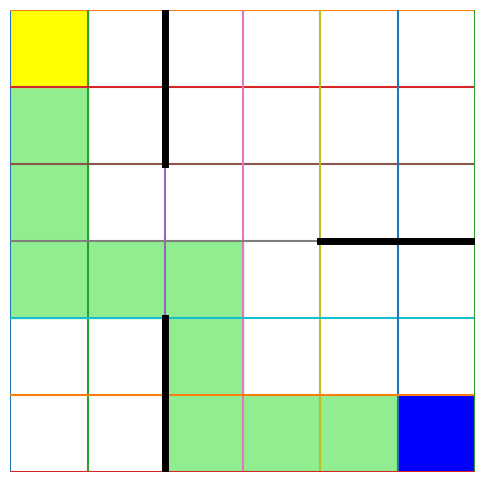

In [ ]:
import matplotlib.pyplot as plt 


def draw_path(result):


    for i in range (7): ## vẽ lưới
        plt.plot([i,i],[0,6])
        plt.plot([0,6],[i,i])
    plt.gca().invert_yaxis()
    plt.axis("off")
    for wall in wall_list: ## vẽ tường
        r1, c1 = wall.a
        r2, c2 = wall.b

        r1 -= 1; c1 -= 1
        r2 -= 1; c2 -= 1
        
        if r1 == r2:
            r = r1
            c = max(c1,c2)
            plt.plot([c,c], [r, r+1], linewidth = 5, color = "black")
        elif c1 == c2:
            c = c1
            r = max(r1,r2)
            plt.plot([c,c+1], [r, r], linewidth = 5, color = "black")

    for point in result:
        r, c = point
        r -= 1; c-=1
        plt.fill(
            [c, c+1, c+1, c],
            [r, r, r+1, r+1],
            color='lightgreen'
        )
    plt.fill([5, 6, 6, 5],[5, 5, 6, 6],color='blue')
    plt.fill([0, 1, 1, 0],[0, 0, 1, 1],color='red')

plt.figure(figsize=(6,6))
plt.xlim(0,6)
plt.ylim(0,6)
draw_path(result)
plt.savefig("maze_bfs.png")
plt.show()

### Tìm đường đi từ ô (1,1) đến ô (6,6) của mê cung bằng DFS

In [35]:
import pprint
from ex2_maze import find_path_DFS

#..
parent2 = find_path_DFS(maze, wall_list, 1, 1, 6, 6)

pprint.pprint(parent)

{(1, 1): None,
 (1, 2): (1, 1),
 (1, 3): (2, 3),
 (1, 4): (1, 3),
 (1, 5): (1, 4),
 (1, 6): (1, 5),
 (2, 1): (1, 1),
 (2, 2): (2, 1),
 (2, 3): (3, 3),
 (2, 4): (2, 3),
 (2, 5): (2, 4),
 (2, 6): (2, 5),
 (3, 1): (2, 1),
 (3, 2): (3, 1),
 (3, 3): (3, 2),
 (3, 4): (3, 3),
 (3, 5): (3, 4),
 (3, 6): (3, 5),
 (4, 1): (3, 1),
 (4, 2): (4, 1),
 (4, 3): (4, 2),
 (4, 4): (4, 3),
 (4, 5): (4, 4),
 (4, 6): (4, 5),
 (5, 1): (4, 1),
 (5, 2): (5, 1),
 (5, 3): (4, 3),
 (5, 4): (5, 3),
 (5, 5): (5, 4),
 (5, 6): (5, 5),
 (6, 1): (5, 1),
 (6, 2): (6, 1),
 (6, 3): (5, 3),
 (6, 4): (6, 3),
 (6, 5): (6, 4),
 (6, 6): (6, 5)}


### Truy vết đường đi

In [36]:
import pprint
from ex2_maze import path

result2 = path(parent2, 1,1,6,6)

pprint.pprint(result2)


[(6, 6),
 (5, 6),
 (4, 6),
 (4, 5),
 (4, 4),
 (3, 4),
 (3, 3),
 (3, 2),
 (2, 2),
 (1, 2),
 (1, 1)]


### Vẽ lại đường đi

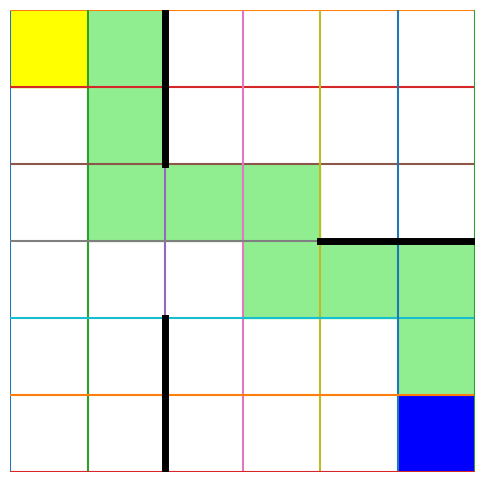

In [41]:
plt.figure(figsize=(6,6))
plt.xlim(0,6)
plt.ylim(0,6)
draw_path(result2)
plt.savefig("maze_dfs.png")
plt.show()

# Kết thúc